In [33]:
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")

In [3]:
data <- read.csv("../results/pep.search.qualscore.20250721.csv")
head(data)

,Spectrum,Probability,Qualscore,Peptide,Peptide_I_L_equal,Source
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.76.76.3,0.0,1.4863926,MSRLGALGGAR,MSRLGALGGAR,pfind_open
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.79.79.4,0.0,0.9451531,GRAEGSEKEESRR,GRAEGSEKEESRR,pfind_open
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.81.81.3,0.0,0.3249771,,,Unidentified
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.82.82.3,0.0,1.6609938,,,Unidentified
5,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.83.83.4,0.0,1.9051905,,,Unidentified
6,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.84.84.3,0.5,2.0290708,,,Unidentified


In [26]:
data$Source <- recode(data$Source,
    "msfragger_closed"= "MSFragger closed search",
    "msfragger_open"= "MSFragger open search",
    "pfind_closed"= "pFind closed search",
    "pfind_open"= "pFind open search",
    "primenovo_punifind"= "PrimeNovo & pUniFind intersection",
    "Unidentified due to Low quality"= "Unidentified (low quality spectra)"
)
my_colors <- c(
  "MSFragger closed search" = "#4C72B0",
  "MSFragger open search" = "#55A868",
  "pFind closed search" = "#C44E52",
  "pFind open search" = "#8172B2",
  "PrimeNovo & pUniFind intersection" = "#FFA500",
  "Unidentified (low quality spectra)" = "grey60"
)

In [43]:
library(ggplot2)

ggplot(data, aes(x = Source, y = Qualscore, fill = Source)) +
  # 小提琴图（分布）
  geom_violin(trim = FALSE, alpha = 0.5) +
  
  # 叠加盒形图（透明填充，仅中间显示）
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA, color = "black") +

  # 美化主题与标签
  labs(title = "Quality Score Distribution by Source",
       x = "Source",
       y = "Spectrum Quality Score") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
  scale_fill_manual(values = my_colors) +
geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  theme(plot.title = element_text(hjust = 0.5))->p
 # 与最后一个组比较 
p+ stat_compare_means(ref.group = 'Unidentified',
                     method = "wilcox.test",
                     label = "p.signif",
                     hide.ns = TRUE,
                      method.args=list(alternative="two.sided")) -> p_1
#   scale_fill_brewer(palette = "Set3")
ggsave(p_1,filename = "../figures/qualscore_by_source.pdf",height = 5,width = 8)

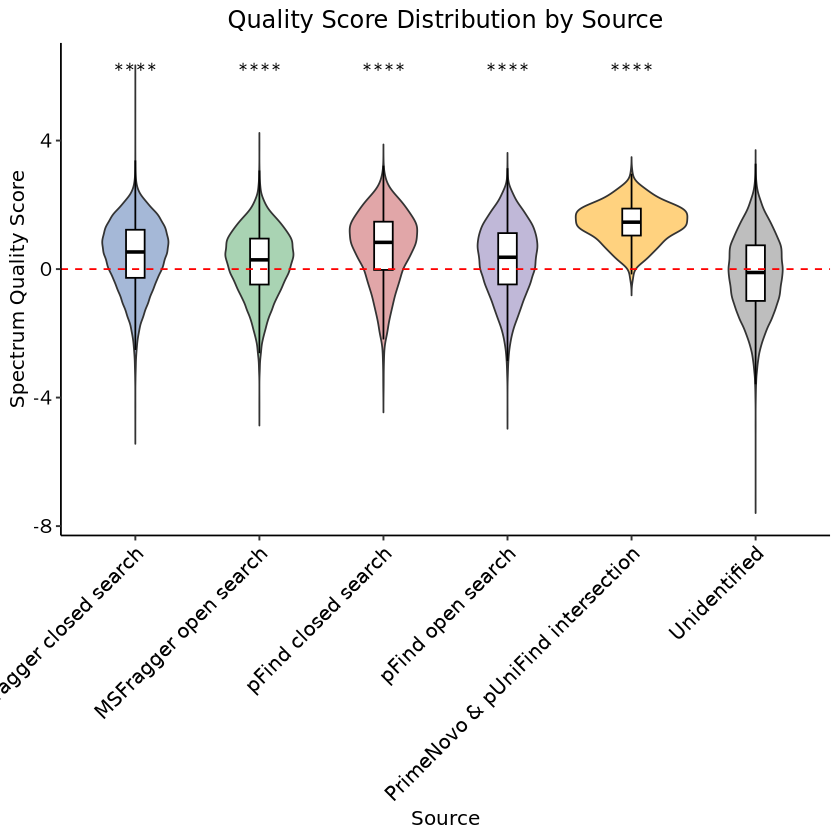

In [44]:
p_1